In [2]:
!pip install numpy tensorflow opencv-python

You should consider upgrading via the '/Users/leathermajesty/notebook/.venv/bin/python3 -m pip install --upgrade pip' command.


In [4]:
print(tf.__version__)
print(keras.__version__)

NameError: name 'tf' is not defined

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_digit_cnn(input_shape=(28, 28, 1), num_classes=10):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])

    return model

model = build_digit_cnn()

# Load the trained weights
model.load_weights("../saved_model/digit_cnn.keras")

# Compile for further training
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/Users/leathermajesty/notebook/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Load MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Same preprocessing used during training
X_test = X_test.astype("float32") / 255.0
X_test = X_test.reshape(-1, 28, 28, 1)

# Predict first 10 images
predictions = model.predict(X_test[:10])

predicted_digits = np.argmax(predictions, axis=1)

print("Actual:   ", y_test[:10])
print("Predicted:", predicted_digits)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


NameError: name 'np' is not defined

In [7]:
#Then check the complete test accuracy:

loss, accuracy = model.evaluate(
    X_test,
    keras.utils.to_categorical(y_test, 10),
    verbose=0
)


print(f"Test accuracy: {accuracy * 100:.2f}%")

Test accuracy: 99.23%


In [8]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def predict_digit(image_path):
    # Load image
    image = Image.open(image_path).convert("L")

    # Resize to model input size
    image = image.resize((28, 28))

    # Convert to NumPy array
    image_array = np.array(image).astype("float32")

    # Normalize
    image_array = image_array / 255.0

    # Add channel dimension and batch dimension
    image_array = image_array.reshape(1, 28, 28, 1)

    # Predict
    prediction = model.predict(image_array, verbose=0)

    digit = np.argmax(prediction[0])
    confidence = prediction[0][digit] * 100

    # Show image
    plt.imshow(image_array[0].reshape(28, 28), cmap="gray")
    plt.title(f"Prediction: {digit} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

    return digit, confidence

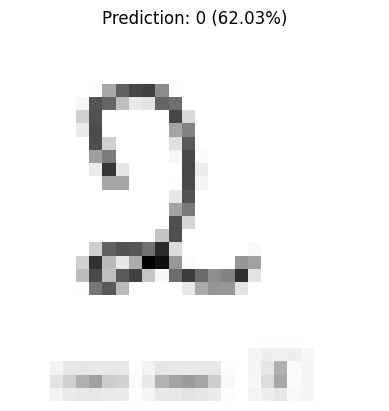

Predicted digit: 0
Confidence: 62.03%


In [9]:
digit, confidence = predict_digit("../test_images/2.png")

print("Predicted digit:", digit)
print("Confidence:", f"{confidence:.2f}%")

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def preprocess_digit(image_path, debug=True):
    """
    Universal handwritten-digit preprocessing.

    Converts different input styles into:
        28x28
        black background
        white digit
        normalized to [0, 1]
    """

    # ============================================================
    # 1. LOAD IMAGE
    # ============================================================

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Could not read image: {image_path}")

    original = img.copy()

    # Make sure we have enough resolution
    if min(img.shape) < 30:
        scale = 4
        img = cv2.resize(
            img,
            None,
            fx=scale,
            fy=scale,
            interpolation=cv2.INTER_CUBIC
        )

    # ============================================================
    # 2. REMOVE SMALL IMAGE NOISE
    # ============================================================

    # Mild Gaussian blur
    blurred = cv2.GaussianBlur(img, (3, 3), 0)

    # ============================================================
    # 3. AUTOMATIC BACKGROUND / POLARITY DETECTION
    # ============================================================

    # Look at pixels around the border.
    # They are usually background.
    border_pixels = np.concatenate([
        blurred[0, :],
        blurred[-1, :],
        blurred[:, 0],
        blurred[:, -1]
    ])

    background_value = np.median(border_pixels)

    # If background is bright:
    #     digit is probably dark
    #
    # If background is dark:
    #     digit is probably bright

    if background_value > 127:
        polarity = "dark_digit"
    else:
        polarity = "bright_digit"

    # ============================================================
    # 4. CREATE TWO POSSIBLE THRESHOLDS
    # ============================================================

    # OTSU
    _, otsu = cv2.threshold(
        blurred,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Adaptive threshold
    adaptive = cv2.adaptiveThreshold(
        blurred,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31,
        10
    )

    # Convert both so that:
    #
    # foreground digit = WHITE
    # background = BLACK

    if polarity == "dark_digit":
        otsu_fg = cv2.bitwise_not(otsu)
        adaptive_fg = cv2.bitwise_not(adaptive)
    else:
        otsu_fg = otsu
        adaptive_fg = adaptive

    # ============================================================
    # 5. SELECT THE BETTER THRESHOLD AUTOMATICALLY
    # ============================================================

    def foreground_score(mask):

        # Fraction of pixels considered foreground
        ratio = np.mean(mask > 0)

        # A digit normally occupies a relatively small portion
        # of the image.
        if ratio < 0.005:
            return -100

        if ratio > 0.60:
            return -100

        # Penalize foreground touching the border heavily.
        border = np.concatenate([
            mask[0, :],
            mask[-1, :],
            mask[:, 0],
            mask[:, -1]
        ])

        border_ratio = np.mean(border > 0)

        score = 1.0

        score -= border_ratio * 5

        # Prefer a reasonable amount of foreground
        if 0.01 < ratio < 0.35:
            score += 2

        return score

    score_otsu = foreground_score(otsu_fg)
    score_adaptive = foreground_score(adaptive_fg)

    if score_otsu >= score_adaptive:
        binary = otsu_fg
    else:
        binary = adaptive_fg

    # ============================================================
    # 6. MORPHOLOGICAL CLEANUP
    # ============================================================

    kernel = np.ones((2, 2), np.uint8)

    # Close tiny gaps in strokes
    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=1
    )

    # Remove tiny isolated noise
    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1
    )

    # ============================================================
    # 7. FIND CONNECTED COMPONENTS
    # ============================================================

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        binary,
        connectivity=8
    )

    h, w = binary.shape
    image_area = h * w

    components = []

    for i in range(1, num_labels):

        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        cw = stats[i, cv2.CC_STAT_WIDTH]
        ch = stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]

        # Ignore microscopic noise
        if area < max(10, image_area * 0.0001):
            continue

        components.append(
            (i, x, y, cw, ch, area)
        )

    if not components:
        raise ValueError(
            "Could not detect a digit. Try a clearer image."
        )

    # ============================================================
    # 8. SELECT DIGIT REGION
    # ============================================================

    # Usually the digit is the largest meaningful component.
    #
    # But instead of blindly selecting the largest component,
    # ignore components that are suspiciously huge.

    valid_components = [
        c for c in components
        if c[5] < image_area * 0.50
    ]

    if valid_components:
        components = valid_components

    # Largest component
    main = max(
        components,
        key=lambda c: c[5]
    )

    _, x, y, cw, ch, area = main

    # ============================================================
    # 9. INCLUDE NEARBY COMPONENTS
    # ============================================================

    # Some handwritten digits can contain disconnected pieces.
    # Include components close to the main digit.

    padding = max(5, int(max(cw, ch) * 0.15))

    x1 = max(0, x - padding)
    y1 = max(0, y - padding)
    x2 = min(w, x + cw + padding)
    y2 = min(h, y + ch + padding)

    # Build mask containing nearby components
    digit_mask = np.zeros_like(binary)

    for component in components:

        label, cx, cy, cwidth, cheight, carea = component

        component_x2 = cx + cwidth
        component_y2 = cy + cheight

        # Check whether component overlaps digit region
        if (
            component_x2 >= x1 and
            cx <= x2 and
            component_y2 >= y1 and
            cy <= y2
        ):
            digit_mask[labels == label] = 255

    # Crop
    cropped = digit_mask[y1:y2, x1:x2]

    # ============================================================
    # 10. ADD PADDING
    # ============================================================

    # We want the digit itself to occupy about 20x20
    # inside the final 28x28 MNIST image.

    ch, cw = cropped.shape

    if ch == 0 or cw == 0:
        raise ValueError("Invalid digit crop.")

    # ============================================================
    # 11. PRESERVE ASPECT RATIO
    # ============================================================

    target_size = 20

    scale = target_size / max(ch, cw)

    new_w = max(1, int(round(cw * scale)))
    new_h = max(1, int(round(ch * scale)))

    resized = cv2.resize(
        cropped,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA
    )

    # ============================================================
    # 12. CREATE MNIST-SIZE CANVAS
    # ============================================================

    canvas = np.zeros((28, 28), dtype=np.uint8)

    # ============================================================
    # 13. CENTER THE DIGIT
    # ============================================================

    # First put it approximately in the center.
    start_x = (28 - new_w) // 2
    start_y = (28 - new_h) // 2

    canvas[
        start_y:start_y + new_h,
        start_x:start_x + new_w
    ] = resized

    # ============================================================
    # 14. CENTER USING CENTER OF MASS
    # ============================================================

    moments = cv2.moments(canvas)

    if moments["m00"] != 0:

        cx = moments["m10"] / moments["m00"]
        cy = moments["m01"] / moments["m00"]

        shift_x = int(round(13.5 - cx))
        shift_y = int(round(13.5 - cy))

        M = np.float32([
            [1, 0, shift_x],
            [0, 1, shift_y]
        ])

        canvas = cv2.warpAffine(
            canvas,
            M,
            (28, 28),
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=0
        )

    # ============================================================
    # 15. SLIGHT STROKE NORMALIZATION
    # ============================================================

    # Don't aggressively thicken.
    # MNIST already contains anti-aliased strokes.

    # Normalize to [0, 1]
    model_input = canvas.astype("float32") / 255.0

    model_input = model_input.reshape(
        1, 28, 28, 1
    )

    # ============================================================
    # 16. DEBUG VISUALIZATION
    # ============================================================

    if debug:

        fig, axes = plt.subplots(
            1, 5,
            figsize=(15, 4)
        )

        axes[0].imshow(
            original,
            cmap="gray"
        )
        axes[0].set_title("Original")

        axes[1].imshow(
            binary,
            cmap="gray"
        )
        axes[1].set_title("Foreground")

        axes[2].imshow(
            cropped,
            cmap="gray"
        )
        axes[2].set_title("Cropped")

        axes[3].imshow(
            resized,
            cmap="gray"
        )
        axes[3].set_title("Resized")

        axes[4].imshow(
            canvas,
            cmap="gray"
        )
        axes[4].set_title("Final 28×28")

        for ax in axes:
            ax.axis("off")

        plt.tight_layout()
        plt.show()

    return model_input

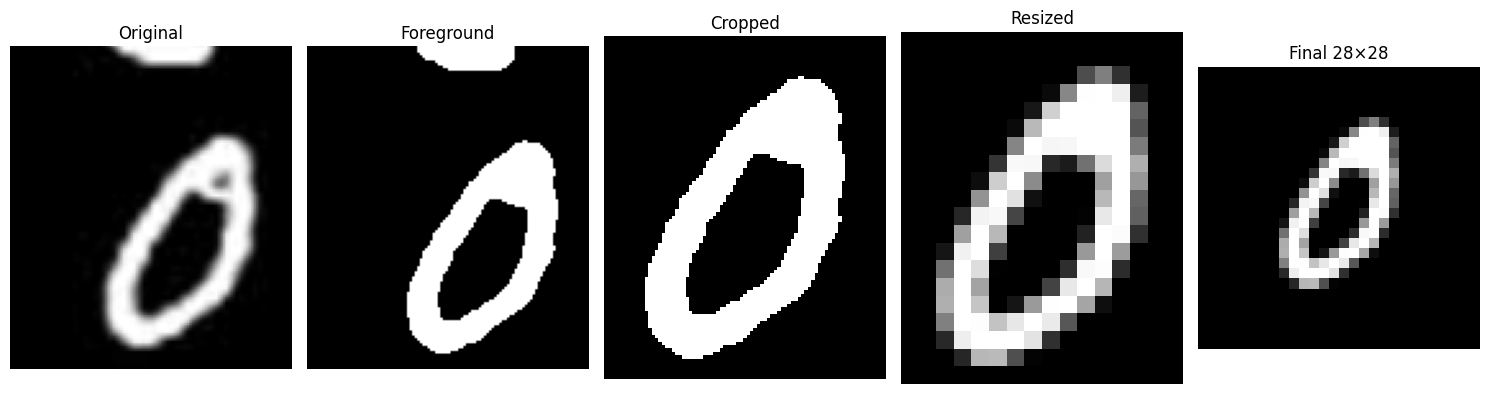

In [23]:
image_path = "../test_images/0.png"

processed = preprocess_digit(image_path)

In [24]:
prediction = model.predict(processed, verbose=0)

digit = np.argmax(prediction[0])
confidence = prediction[0][digit] * 100

print("Predicted digit:", digit)
print(f"Confidence: {confidence:.2f}%")

Predicted digit: 0
Confidence: 99.97%


In [25]:
for i, probability in enumerate(prediction[0]):
    print(f"{i}: {probability * 100:.2f}%")

0: 99.97%
1: 0.00%
2: 0.00%
3: 0.00%
4: 0.00%
5: 0.00%
6: 0.00%
7: 0.00%
8: 0.00%
9: 0.02%
